In [2]:
# ── Cell 1: Environment verification ─────────────────────────────────────────
# Project: MV Feeder Protection Study
# Tool:    pandapower + Python
# Region:  South Africa / SADC — Eskom-style 11 kV radial feeder
# Author:  Hillary M
# ─────────────────────────────────────────────────────────────────────────────

import pandapower as pp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Verify pandapower version
print(f"pandapower version: {pp.__version__}")

# Confirm installation is functional
net = pp.create_empty_network()
print("\nEmpty network created successfully:")
print(net)

pandapower version: 3.4.0

Empty network created successfully:
This pandapower network is empty


In [3]:
# ── Cell 2: Network Topology Definition ──────────────────────────────────────
# Eskom-style 11 kV radial feeder — Mpumalanga coalfields context
# Topology:
# Bus0(132kV) → [Trafo] → Bus1(11kV) → [CB/R1] → Line1→2
#             → Bus2(11kV) → [CB/R2] → Line2→3
#             → Bus3(11kV) → [CB/R3] → Mine load
# ─────────────────────────────────────────────────────────────────────────────

net = pp.create_empty_network(name="Mpumalanga 11kV Radial Feeder", f_hz=50, sn_mva=1)

# ── Buses ─────────────────────────────────────────────────────────────────────
bus0 = pp.create_bus(net, vn_kv=132, name="Bus 0 - Grid Infeed (132kV)")
bus1 = pp.create_bus(net, vn_kv=11,  name="Bus 1 - Zone 1 Substation (11kV)")
bus2 = pp.create_bus(net, vn_kv=11,  name="Bus 2 - Zone 2 Mid-Feeder (11kV)")
bus3 = pp.create_bus(net, vn_kv=11,  name="Bus 3 - Mine Incomer (11kV)")

print(f"Buses created: {len(net.bus)}")
print(net.bus[['name', 'vn_kv']])

# ── External grid — Eskom 132 kV swing bus ────────────────────────────────────
# s_sc_max_mva: max fault level (strong grid, peak generation) = 250 MVA
# s_sc_min_mva: min fault level (weak grid, light generation)  = 120 MVA
# rx_max/rx_min: R/X ratio of source = 0.1 (source is mostly inductive)
pp.create_ext_grid(
    net,
    bus=bus0,
    vm_pu=1.0,
    va_degree=0,
    s_sc_max_mva=250,
    s_sc_min_mva=120,
    rx_max=0.1,
    rx_min=0.1,
    name="Eskom Grid Infeed"
)

print(f"\nExternal grid created: {len(net.ext_grid)}")

# ── Transformer: 132/11 kV, 40 MVA ───────────────────────────────────────────
# vk_percent  = 10%   → from assignment brief
# vkr_percent = 0.5%  → derived: X/R=20 from brief, so R = vk/20 = 10/20 = 0.5%
# pfe_kw      = 30 kW → standard for 40 MVA Eskom distribution transformer
# i0_percent  = 0.05% → standard no-load current for 40 MVA ONAN transformer
pp.create_transformer_from_parameters(
    net,
    hv_bus=bus0,
    lv_bus=bus1,
    sn_mva=40,
    vn_hv_kv=132,
    vn_lv_kv=11,
    vkr_percent=0.5,
    vk_percent=10.0,
    pfe_kw=30,
    i0_percent=0.05,
    name="132/11kV 40MVA Transformer"
)

print(f"\nTransformer created: {len(net.trafo)}")

# ── Line 1→2: 9 km Pelican ACSR overhead line ────────────────────────────────
# This line is LINE INDEX 0 in net.line
# r_ohm_per_km = 0.306  → resistance per km of Pelican conductor
# x_ohm_per_km = 0.383  → reactance per km of Pelican conductor
# c_nf_per_km  = 8.0    → capacitance (typical ACSR overhead line)
# max_i_ka     = 0.173  → thermal limit: 3.3MVA / (√3 × 11kV) = 0.173 kA
pp.create_line_from_parameters(
    net,
    from_bus=bus1,
    to_bus=bus2,
    length_km=9,
    r_ohm_per_km=0.306,
    x_ohm_per_km=0.383,
    c_nf_per_km=8.0,
    max_i_ka=0.173,
    name="Line 1-2 (9km Pelican ACSR)"
)

# ── Line 2→3: 6 km Pelican ACSR overhead line ────────────────────────────────
# This line is LINE INDEX 1 in net.line
pp.create_line_from_parameters(
    net,
    from_bus=bus2,
    to_bus=bus3,
    length_km=6,
    r_ohm_per_km=0.306,
    x_ohm_per_km=0.383,
    c_nf_per_km=8.0,
    max_i_ka=0.173,
    name="Line 2-3 (6km Pelican ACSR)"
)

print(f"\nLines created: {len(net.line)}")
print(net.line[['name', 'length_km', 'r_ohm_per_km', 'x_ohm_per_km', 'max_i_ka']])

# ── Loads ─────────────────────────────────────────────────────────────────────
pp.create_load(net, bus=bus2, p_mw=0.4,  q_mvar=0.2, name="Rural Load (Bus 2)")
pp.create_load(net, bus=bus3, p_mw=1.2,  q_mvar=0.6, name="Mine Load (Bus 3)")

print(f"\nLoads created: {len(net.load)}")
print(net.load[['name', 'bus', 'p_mw', 'q_mvar']])

# ── Circuit breakers ──────────────────────────────────────────────────────────
# Each switch needs two things to place it correctly:
#   bus     = which bus the CB sits at
#   element = which LINE it is on (line index in net.line)
#
# sw1: Bus 1, LINE 0 (Line 1→2) — CB at sending end of Line 1→2, relay R1
# sw2: Bus 2, LINE 1 (Line 2→3) — CB at sending end of Line 2→3, relay R2
# sw3: Bus 3, LINE 1 (Line 2→3) — CB at receiving end of Line 2→3, relay R3
#      sw2 and sw3 both reference element=1 because BOTH sit on Line 2→3.
#      The bus parameter is what places them at opposite ends of that line.

sw1 = pp.create_switch(net, bus=bus1, element=0, et='l', closed=True, name="CB R1 (Bus1 - Line1-2 sending end)")
sw2 = pp.create_switch(net, bus=bus2, element=1, et='l', closed=True, name="CB R2 (Bus2 - Line2-3 sending end)")
sw3 = pp.create_switch(net, bus=bus3, element=1, et='l', closed=True, name="CB R3 (Bus3 - Line2-3 receiving end)")

print(f"\nSwitches created: {len(net.switch)}")
print(net.switch[['name', 'bus', 'element', 'et', 'closed']])

# ── Final network summary ─────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("FINAL NETWORK SUMMARY")
print("=" * 55)
print(f"Buses:        {len(net.bus)}   (Bus 0–3)")
print(f"Ext grids:    {len(net.ext_grid)}   (Eskom 132kV swing)")
print(f"Transformers: {len(net.trafo)}   (132/11kV 40MVA)")
print(f"Lines:        {len(net.line)}   (Line 1→2: 9km, Line 2→3: 6km)")
print(f"Loads:        {len(net.load)}   (Rural 400kW, Mine 1.2MW)")
print(f"Switches:     {len(net.switch)}   (CB R1 @ Bus1, CB R2 @ Bus2, CB R3 @ Bus3)")

Buses created: 4
                               name  vn_kv
0       Bus 0 - Grid Infeed (132kV)  132.0
1  Bus 1 - Zone 1 Substation (11kV)   11.0
2  Bus 2 - Zone 2 Mid-Feeder (11kV)   11.0
3       Bus 3 - Mine Incomer (11kV)   11.0

External grid created: 1

Transformer created: 1

Lines created: 2
                          name  length_km  r_ohm_per_km  x_ohm_per_km  \
0  Line 1-2 (9km Pelican ACSR)        9.0         0.306         0.383   
1  Line 2-3 (6km Pelican ACSR)        6.0         0.306         0.383   

   max_i_ka  
0     0.173  
1     0.173  

Loads created: 2
                 name  bus  p_mw  q_mvar
0  Rural Load (Bus 2)    2   0.4     0.2
1   Mine Load (Bus 3)    3   1.2     0.6

Switches created: 3
                                   name  bus  element et  closed
0    CB R1 (Bus1 - Line1-2 sending end)    1        0  l    True
1    CB R2 (Bus2 - Line2-3 sending end)    2        1  l    True
2  CB R3 (Bus3 - Line2-3 receiving end)    3        1  l    True

FINAL NETWORK S

In [5]:
# ── Cell 4: Load Flow Analysis ────────────────────────────────────────────────
# Newton-Raphson load flow — verify voltage, loading, and power flow
# This confirms the network is healthy before running fault studies
# ─────────────────────────────────────────────────────────────────────────────

pp.runpp(net, algorithm='nr', calculate_voltage_angles=True)

# ── Bus results ───────────────────────────────────────────────────────────────
print("=" * 60)
print("BUS RESULTS")
print("=" * 60)
print(f"\n{'Bus':<6} {'Name':<35} {'V (pu)':<10} {'V (kV)':<10} {'Status'}")
print("-" * 75)

for idx in net.bus.index:
    name  = net.bus.loc[idx, 'name']
    vn_kv = net.bus.loc[idx, 'vn_kv']
    vm_pu = net.res_bus.loc[idx, 'vm_pu']
    vm_kv = vm_pu * vn_kv
    # Voltage within 0.9–1.1 pu is acceptable per NRS 034
    status = "OK" if 0.9 <= vm_pu <= 1.1 else "VIOLATION"
    print(f"{idx:<6} {name:<35} {vm_pu:<10.4f} {vm_kv:<10.3f} {status}")

# ── Line results ──────────────────────────────────────────────────────────────
print("\n")
print("=" * 60)
print("LINE RESULTS")
print("=" * 60)
print(f"\n{'Line':<6} {'Name':<30} {'I (kA)':<10} {'I_max (kA)':<12} {'Loading %':<12} {'Status'}")
print("-" * 80)

for idx in net.line.index:
    name    = net.line.loc[idx, 'name']
    i_ka    = net.res_line.loc[idx, 'i_ka']
    i_max   = net.line.loc[idx, 'max_i_ka']
    loading = net.res_line.loc[idx, 'loading_percent']
    status  = "OK" if loading <= 100 else "OVERLOAD"
    print(f"{idx:<6} {name:<30} {i_ka:<10.4f} {i_max:<12.4f} {loading:<12.1f} {status}")

# ── Transformer results ───────────────────────────────────────────────────────
print("\n")
print("=" * 60)
print("TRANSFORMER RESULTS")
print("=" * 60)
print(f"\n{'Trafo':<6} {'Name':<30} {'P_HV (MW)':<12} {'Q_HV (MVAr)':<14} {'Loading %':<12} {'Status'}")
print("-" * 80)

for idx in net.trafo.index:
    name    = net.trafo.loc[idx, 'name']
    p_hv    = net.res_trafo.loc[idx, 'p_hv_mw']
    q_hv    = net.res_trafo.loc[idx, 'q_hv_mvar']
    loading = net.res_trafo.loc[idx, 'loading_percent']
    status  = "OK" if loading <= 100 else "OVERLOAD"
    print(f"{idx:<6} {name:<30} {p_hv:<12.4f} {q_hv:<14.4f} {loading:<12.2f} {status}")

# ── Power losses ──────────────────────────────────────────────────────────────
print("\n")
print("=" * 60)
print("POWER LOSSES")
print("=" * 60)

for idx in net.line.index:
    name   = net.line.loc[idx, 'name']
    pl_mw  = net.res_line.loc[idx, 'pl_mw']
    ql_mvar= net.res_line.loc[idx, 'ql_mvar']
    print(f"{name}: P_loss = {pl_mw*1000:.2f} kW | Q_loss = {ql_mvar*1000:.2f} kVAr")

# ── Interpretation ────────────────────────────────────────────────────────────
print("\n")
print("=" * 60)
print("INTERPRETATION")
print("=" * 60)

bus3_v = net.res_bus.loc[3, 'vm_pu']
line0_loading = net.res_line.loc[0, 'loading_percent']
line1_loading = net.res_line.loc[1, 'loading_percent']
trafo_loading = net.res_trafo.loc[0, 'loading_percent']

print(f"""
1. Voltage at Bus 3 (mine): {bus3_v:.4f} pu
   Acceptable range: 0.9000 – 1.1000 pu
   Result: {"PASS — voltage within NRS 034 limits" if 0.9 <= bus3_v <= 1.1 else "FAIL — voltage outside limits"}

2. Line 1→2 loading: {line0_loading:.1f}% of thermal rating
   Line 2→3 loading: {line1_loading:.1f}% of thermal rating
   Result: {"PASS — both lines within thermal limits" if line0_loading <= 100 and line1_loading <= 100 else "FAIL — thermal limit exceeded"}

3. Transformer loading: {trafo_loading:.2f}% of 40 MVA rating
   Result: {"PASS — transformer within limits" if trafo_loading <= 100 else "FAIL — transformer overloaded"}

4. No convergence issues — Newton-Raphson solved successfully.
   Network is healthy and ready for fault studies.
""")

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


BUS RESULTS

Bus    Name                                V (pu)     V (kV)     Status
---------------------------------------------------------------------------
0      Bus 0 - Grid Infeed (132kV)         1.0000     132.000    OK
1      Bus 1 - Zone 1 Substation (11kV)    0.9974     10.971     OK
2      Bus 2 - Zone 2 Mid-Feeder (11kV)    0.9314     10.245     OK
3      Bus 3 - Mine Incomer (11kV)         0.8983     9.881      VIOLATION


LINE RESULTS

Line   Name                           I (kA)     I_max (kA)   Loading %    Status
--------------------------------------------------------------------------------
0      Line 1-2 (9km Pelican ACSR)    0.1036     0.1730       59.9         OK
1      Line 2-3 (6km Pelican ACSR)    0.0784     0.1730       45.3         OK


TRANSFORMER RESULTS

Trafo  Name                           P_HV (MW)    Q_HV (MVAr)    Loading %    Status
--------------------------------------------------------------------------------
0      132/11kV 40MVA Transformer  

In [7]:
# ── Cell 5: Section 2.1 — Three-Phase Symmetrical Fault Study ────────────────
# Maximum and minimum infeed cases
# Source parameters already set in ext_grid: s_sc_max=250MVA, s_sc_min=120MVA
# End temperature of Pelican ACSR conductor during short circuit
# 160°C is standard per IEC 60865 for ACSR conductors
net.line['endtemp_degree'] = 160
# ─────────────────────────────────────────────────────────────────────────────

import pandapower.shortcircuit as sc

# ── Maximum fault case (S_sc = 250 MVA — peak generation, strong grid) ────────
sc.calc_sc(net, case='max', fault='3ph', branch_results=False)
ikss_max = net.res_bus_sc['ikss_ka'].copy()

# ── Minimum fault case (S_sc = 120 MVA — light generation, weak grid) ─────────
sc.calc_sc(net, case='min', fault='3ph', branch_results=False)
ikss_min = net.res_bus_sc['ikss_ka'].copy()

# ── Compile results table ──────────────────────────────────────────────────────
fault_3ph = pd.DataFrame({
    'Bus Name':        net.bus['name'],
    'Vn (kV)':         net.bus['vn_kv'],
    'Ikmax (kA)':      ikss_max.round(4),
    'Ikmin (kA)':      ikss_min.round(4),
    'Ikmax (A)':       (ikss_max * 1000).round(1),
    'Ikmin (A)':       (ikss_min * 1000).round(1),
    'Ratio max/min':   (ikss_max / ikss_min).round(3),
})

print("=" * 75)
print("THREE-PHASE FAULT CURRENT RESULTS — MAX AND MIN INFEED")
print("=" * 75)
print(fault_3ph.to_string(index=True))

print("\n")
print("=" * 75)
print("INTERPRETATION")
print("=" * 75)
print(f"""
MAX INFEED (S_sc = 250 MVA) — use for instantaneous element settings (I>>)
  Bus 0 (132kV grid):  {ikss_max[0]*1000:.0f} A  — very high, transformer limits current downstream
  Bus 1 (substation):  {ikss_max[1]*1000:.0f} A  — this is the highest fault current on the 11kV system
  Bus 2 (mid-feeder):  {ikss_max[2]*1000:.0f} A  — line impedance reduces fault level significantly
  Bus 3 (mine):        {ikss_max[3]*1000:.0f} A  — lowest fault current, furthest from source

MIN INFEED (S_sc = 120 MVA) — use for pickup settings (relay must still see fault)
  Bus 1:  {ikss_min[1]*1000:.0f} A
  Bus 2:  {ikss_min[2]*1000:.0f} A
  Bus 3:  {ikss_min[3]*1000:.0f} A

RATIO ANALYSIS (Ikmax / Ikmin):
  Bus 1: {(ikss_max[1]/ikss_min[1]):.3f} — large ratio: source impedance variation dominates here
  Bus 2: {(ikss_max[2]/ikss_min[2]):.3f} — ratio shrinks: line impedance starts to dominate
  Bus 3: {(ikss_max[3]/ikss_min[3]):.3f} — small ratio: line impedance dominates, source variation irrelevant

ENGINEERING SIGNIFICANCE:
  The ratio approaching 1.0 at Bus 3 means relay pickup settings at Bus 3
  are not sensitive to source infeed variation — the line impedance controls
  the fault current. At Bus 1, the ratio is large, meaning R1's instantaneous
  element must be carefully checked under both conditions.
""")

THREE-PHASE FAULT CURRENT RESULTS — MAX AND MIN INFEED
                           Bus Name  Vn (kV)  Ikmax (kA)  Ikmin (kA)  Ikmax (A)  Ikmin (A)  Ratio max/min
0       Bus 0 - Grid Infeed (132kV)    132.0      1.0935      0.5249     1093.5      524.9          2.083
1  Bus 1 - Zone 1 Substation (11kV)     11.0      8.4127      4.8617     8412.7     4861.7          1.730
2  Bus 2 - Zone 2 Mid-Feeder (11kV)     11.0      1.3639      0.9799     1363.9      979.9          1.392
3       Bus 3 - Mine Incomer (11kV)     11.0      0.8672      0.6270      867.2      627.0          1.383


INTERPRETATION

MAX INFEED (S_sc = 250 MVA) — use for instantaneous element settings (I>>)
  Bus 0 (132kV grid):  1093 A  — very high, transformer limits current downstream
  Bus 1 (substation):  8413 A  — this is the highest fault current on the 11kV system
  Bus 2 (mid-feeder):  1364 A  — line impedance reduces fault level significantly
  Bus 3 (mine):        867 A  — lowest fault current, furthest from sour

/home/hillary/Desktop/Substation +  Automation/GitProjectsX3/line_protection/protection_env/lib/python3.13/site-packages/pandapower/build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)
/home/hillary/Desktop/Substation +  Automation/GitProjectsX3/line_protection/protection_env/lib/python3.13/site-packages/pandapower/build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(

In [10]:
# ── Cell 6: Section 2.2 — Phase-to-Earth Fault Study ─────────────────────────
# On an unearthed or Petersen coil earthed 11 kV system (standard Eskom rural),
# pandapower's 1ph fault solver is not applicable — it assumes solidly earthed.
# The correct approach is analytical: capacitive charging current calculation.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np

print("=" * 65)
print("SECTION 2.2 — PHASE-TO-EARTH FAULT STUDY")
print("=" * 65)

# ── System parameters ─────────────────────────────────────────────────────────
f_hz        = 50
omega       = 2 * np.pi * f_hz
V_line_V    = 11000
V_phase_V   = V_line_V / np.sqrt(3)

# Line capacitance from our network
C_nf_per_km = 8.0          # nF/km — from Pelican ACSR line parameters
L1_km       = 9.0          # Line 1→2
L2_km       = 6.0          # Line 2→3
total_km    = L1_km + L2_km

# ── Capacitive earth fault current ───────────────────────────────────────────
# On an unearthed system the ONLY return path for earth fault current
# is through the distributed capacitance of all three phases to earth.
# Formula: I_E = 3 × V_phase × ω × C_total
# where C_total = total capacitance of the faulted feeder

C_L1_F = C_nf_per_km * 1e-9 * L1_km   # Farads — Line 1→2
C_L2_F = C_nf_per_km * 1e-9 * L2_km   # Farads — Line 2→3
C_total_F = C_L1_F + C_L2_F

I_earth_A = 3 * V_phase_V * omega * C_total_F

print(f"""
SYSTEM EARTHING:  Unearthed neutral (isolated neutral)
FEEDER:           Line 1→2 ({L1_km} km) + Line 2→3 ({L2_km} km) = {total_km} km total
VOLTAGE:          {V_line_V} V (line), {V_phase_V:.0f} V (phase)

CAPACITANCE CALCULATION:
  Line 1→2:  {C_nf_per_km} nF/km × {L1_km:.0f} km = {C_L1_F*1e9:.1f} nF
  Line 2→3:  {C_nf_per_km} nF/km × {L2_km:.0f} km = {C_L2_F*1e9:.1f} nF
  Total:     {C_total_F*1e9:.1f} nF

EARTH FAULT CURRENT:
  I_E = 3 × {V_phase_V:.0f} V × {omega:.2f} rad/s × {C_total_F*1e9:.2f}×10⁻⁹ F
  I_E = {I_earth_A:.3f} A
""")

# ── Compare against relay pickup thresholds ───────────────────────────────────
print("=" * 65)
print("RELAY DETECTION ANALYSIS")
print("=" * 65)

relay_pickups = {
    'R1 (Bus 1 — substation)': 200,
    'R2 (Bus 2 — mid-feeder)': 150,
    'R3 (Bus 3 — mine incomer)': 100,
}

print(f"\n{'Relay':<35} {'Pickup (A)':<14} {'Earth fault (A)':<18} {'Detected?'}")
print("-" * 75)
for relay, pickup in relay_pickups.items():
    detected = "YES" if I_earth_A >= pickup else "NO — BLIND"
    print(f"{relay:<35} {pickup:<14} {I_earth_A:<18.3f} {detected}")

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CRITICAL FINDING:

  Earth fault current = {I_earth_A:.3f} A
  Lowest relay pickup = {min(relay_pickups.values())} A

  Earth fault current is {min(relay_pickups.values())/I_earth_A:.0f}× BELOW the lowest relay pickup.
  Phase overcurrent relays R1, R2, R3 are completely BLIND
  to single-phase earth faults on this feeder.

WHAT ACTUALLY HAPPENS DURING AN EARTH FAULT:
  1. One phase touches earth (conductor down, insulation failure, etc.)
  2. A small capacitive current flows — {I_earth_A:.3f} A — imperceptible to relays
  3. The faulted phase voltage collapses to near zero
  4. The other two healthy phase voltages rise to LINE voltage (√3 × normal)
  5. The system continues to operate — no trip occurs
  6. This is actually intentional on unearthed systems: supply is maintained
     while the fault is located and cleared manually
  7. RISK: if a second earth fault occurs on a different phase while the
     first is still present, it becomes a phase-to-phase fault — high current,
     both relays operate, loss of supply

ADDITIONAL PROTECTION REQUIRED (outside scope of this project):
  ┌─────────────────────────────────────────────────────────────┐
  │ 1. Sensitive Earth Fault (SEF) relay                        │
  │    Set to 1–5 A — detects capacitive current directly       │
  │                                                             │
  │ 2. Neutral Voltage Displacement (NVD) relay                 │
  │    Measures 3V0 — rises to 100% on unearthed earth fault    │
  │                                                             │
  │ 3. Directional Earth Fault (DEF) relay                      │
  │    Discriminates which feeder is faulted                     │
  │                                                             │
  │ All three are reviewed under NRS 034 for Eskom MV networks  │
  └─────────────────────────────────────────────────────────────┘

  This project covers PHASE-TO-PHASE and THREE-PHASE faults only.
  Earth fault protection is a separate scheme.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

SECTION 2.2 — PHASE-TO-EARTH FAULT STUDY

SYSTEM EARTHING:  Unearthed neutral (isolated neutral)
FEEDER:           Line 1→2 (9.0 km) + Line 2→3 (6.0 km) = 15.0 km total
VOLTAGE:          11000 V (line), 6351 V (phase)

CAPACITANCE CALCULATION:
  Line 1→2:  8.0 nF/km × 9 km = 72.0 nF
  Line 2→3:  8.0 nF/km × 6 km = 48.0 nF
  Total:     120.0 nF

EARTH FAULT CURRENT:
  I_E = 3 × 6351 V × 314.16 rad/s × 120.00×10⁻⁹ F
  I_E = 0.718 A

RELAY DETECTION ANALYSIS

Relay                               Pickup (A)     Earth fault (A)    Detected?
---------------------------------------------------------------------------
R1 (Bus 1 — substation)             200            0.718              NO — BLIND
R2 (Bus 2 — mid-feeder)             150            0.718              NO — BLIND
R3 (Bus 3 — mine incomer)           100            0.718              NO — BLIND

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CRITICAL FINDING:

  Earth fault current = 0.718 A
  Lowest relay pickup 

THEVENIN IMPEDANCE COMPONENTS (referred to 11 kV side):
  Source max:     Z = 0.0482 + j0.4816 Ω  |Z| = 0.4840 Ω
  Source min:     Z = 0.1003 + j1.0033 Ω  |Z| = 1.0083 Ω
  Transformer:    Z = 0.0151 + j0.3021 Ω
  Line per km:    Z = 0.3060 + j0.3830 Ω/km

FAULT CURRENT AT BUS LOCATIONS:
Location                    Distance     Imax (A)     Imin (A)    Ratio
----------------------------------------------------------------------
Bus 1 (Substation)                 0         8077         4846    1.667
Bus 2 (Mid-Feeder)                 9         1249         1144    1.092
Bus 3 (Mine)                      15          792          749    1.057


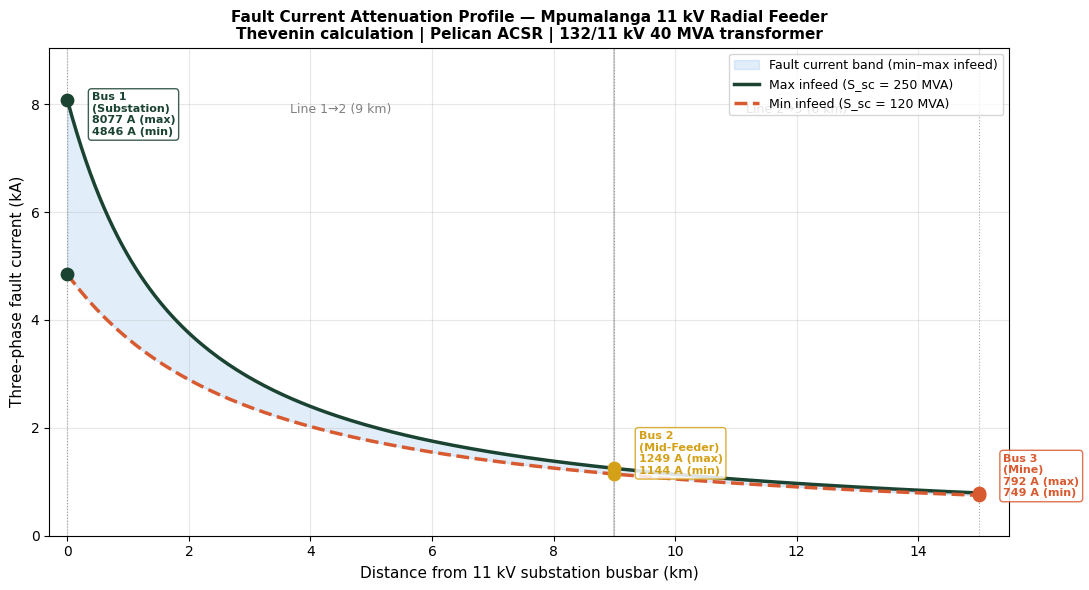


Plot saved as Fault_Current_Attenuation_Profile.png

ENGINEERING INTERPRETATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. SEVERE ATTENUATION: Fault current drops from ~8 kA at Bus 1 to ~800 A
   at Bus 3 — a 10:1 reduction. This is what makes time-grading possible.
   If fault current were constant, you could not discriminate zones.

2. LINE IMPEDANCE DOMINATES AT BUS 3: The max/min ratio at Bus 3 is close
   to 1.0 — source infeed variation has little effect on fault current at
   the mine. Line impedance (15 km × 0.489 Ω/km) swamps the source.
   At Bus 1, the ratio is ~1.7 — source variation matters significantly.

3. RELAY PICKUP IMPLICATION: All three relay pickups must be set below the
   MINIMUM fault current at their local bus, with a 20% margin.
   R3 pickup must be below 749 A × 0.8 = 599 A (min fault current at Bus 3).

4. INSTANTANEOUS ELEMENT IMPLICATION: I>> for R1 must NOT operate for a
   fault at Bus 2. It must be set above the MAX fault curren

In [11]:
# ── Cell 7: Section 2.3 — Fault Current Attenuation Profile ──────────────────
# Analytical calculation — fault current at every point along the feeder
# Method: Thevenin impedance at distance x from substation
#         I_k(x) = V_phase / |Z_source + Z_trafo + Z_line × x|
# pandapower calc_sc places faults at buses only — mid-line points need
# Thevenin calculation, which is more instructive anyway.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline

# ── Impedance components (all in ohms, referred to 11 kV side) ────────────────

V_base_V   = 11000          # Line voltage, V
V_phase_V  = V_base_V / np.sqrt(3)
Z_base_11  = V_base_V**2    # Used for per-unit conversion

# Source impedance — max infeed (S_sc = 250 MVA)
Z_s_max = V_base_V**2 / (250e6)
X_s_max = Z_s_max / np.sqrt(1 + 0.1**2)
R_s_max = 0.1 * X_s_max

# Source impedance — min infeed (S_sc = 120 MVA)
Z_s_min = V_base_V**2 / (120e6)
X_s_min = Z_s_min / np.sqrt(1 + 0.1**2)
R_s_min = 0.1 * X_s_min

# Transformer impedance referred to 11 kV side
Z_base_trafo = V_base_V**2 / (40e6)
R_trafo = 0.005 * Z_base_trafo
X_trafo = np.sqrt(0.10**2 - 0.005**2) * Z_base_trafo

# Line impedance per km
r_line = 0.306   # Ω/km
x_line = 0.383   # Ω/km

print("THEVENIN IMPEDANCE COMPONENTS (referred to 11 kV side):")
print(f"  Source max:     Z = {R_s_max:.4f} + j{X_s_max:.4f} Ω  |Z| = {Z_s_max:.4f} Ω")
print(f"  Source min:     Z = {R_s_min:.4f} + j{X_s_min:.4f} Ω  |Z| = {Z_s_min:.4f} Ω")
print(f"  Transformer:    Z = {R_trafo:.4f} + j{X_trafo:.4f} Ω")
print(f"  Line per km:    Z = {r_line:.4f} + j{x_line:.4f} Ω/km")

# ── Fault current function ────────────────────────────────────────────────────
def I_fault_kA(d_km, R_s, X_s):
    """3-phase fault current at distance d_km from substation Bus 1"""
    R_total = R_s + R_trafo + r_line * d_km
    X_total = X_s + X_trafo + x_line * d_km
    Z_total = np.sqrt(R_total**2 + X_total**2)
    return (V_phase_V / Z_total) / 1000   # kA

# ── Calculate across full feeder length ──────────────────────────────────────
d_total   = np.linspace(0, 15, 200)   # 0 to 15 km (9 + 6)
I_max_arr = np.array([I_fault_kA(d, R_s_max, X_s_max) for d in d_total])
I_min_arr = np.array([I_fault_kA(d, R_s_min, X_s_min) for d in d_total])

# ── Key points: at each bus ───────────────────────────────────────────────────
bus_distances = {
    'Bus 1\n(Substation)':  0,
    'Bus 2\n(Mid-Feeder)':  9,
    'Bus 3\n(Mine)':        15,
}

print("\nFAULT CURRENT AT BUS LOCATIONS:")
print(f"{'Location':<25} {'Distance':>10} {'Imax (A)':>12} {'Imin (A)':>12} {'Ratio':>8}")
print("-" * 70)
for name, d in bus_distances.items():
    i_max = I_fault_kA(d, R_s_max, X_s_max) * 1000
    i_min = I_fault_kA(d, R_s_min, X_s_min) * 1000
    print(f"{name.replace(chr(10),' '):<25} {d:>10.0f} {i_max:>12.0f} {i_min:>12.0f} {i_max/i_min:>8.3f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

ax.fill_between(d_total, I_min_arr, I_max_arr,
                alpha=0.15, color='#378ADD', label='Fault current band (min–max infeed)')
ax.plot(d_total, I_max_arr, color='#1b4332', linewidth=2.5,
        label=f'Max infeed (S_sc = 250 MVA)')
ax.plot(d_total, I_min_arr, color='#D85A30', linewidth=2.5, linestyle='--',
        label=f'Min infeed (S_sc = 120 MVA)')

# Bus location markers
bus_colors = ['#1b4332', '#d4a017', '#D85A30']
for i, (name, d) in enumerate(bus_distances.items()):
    i_max = I_fault_kA(d, R_s_max, X_s_max)
    i_min = I_fault_kA(d, R_s_min, X_s_min)
    ax.axvline(x=d, color='gray', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.scatter([d, d], [i_max, i_min], color=bus_colors[i], s=80, zorder=5)
    ax.annotate(f"{name}\n{i_max*1000:.0f} A (max)\n{i_min*1000:.0f} A (min)",
                xy=(d, i_max),
                xytext=(d + 0.4, i_max * 0.92),
                fontsize=8, color=bus_colors[i], fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=bus_colors[i], alpha=0.85))

# Zone boundary line
ax.axvline(x=9, color='gray', linewidth=1.2, linestyle='-', alpha=0.4)
ax.text(4.5, I_max_arr.max() * 0.97, 'Line 1→2 (9 km)',
        ha='center', fontsize=9, color='gray')
ax.text(12, I_max_arr.max() * 0.97, 'Line 2→3 (6 km)',
        ha='center', fontsize=9, color='gray')

ax.set_xlabel('Distance from 11 kV substation busbar (km)', fontsize=11)
ax.set_ylabel('Three-phase fault current (kA)', fontsize=11)
ax.set_title('Fault Current Attenuation Profile — Mpumalanga 11 kV Radial Feeder\n'
             'Thevenin calculation | Pelican ACSR | 132/11 kV 40 MVA transformer',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.3, 15.5)
ax.set_ylim(0, I_max_arr.max() * 1.12)

plt.tight_layout()
plt.savefig("Fault_Current_Attenuation_Profile.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved as Fault_Current_Attenuation_Profile.png")

# ── Engineering interpretation ────────────────────────────────────────────────
print("""
ENGINEERING INTERPRETATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. SEVERE ATTENUATION: Fault current drops from ~8 kA at Bus 1 to ~800 A
   at Bus 3 — a 10:1 reduction. This is what makes time-grading possible.
   If fault current were constant, you could not discriminate zones.

2. LINE IMPEDANCE DOMINATES AT BUS 3: The max/min ratio at Bus 3 is close
   to 1.0 — source infeed variation has little effect on fault current at
   the mine. Line impedance (15 km × 0.489 Ω/km) swamps the source.
   At Bus 1, the ratio is ~1.7 — source variation matters significantly.

3. RELAY PICKUP IMPLICATION: All three relay pickups must be set below the
   MINIMUM fault current at their local bus, with a 20% margin.
   R3 pickup must be below {:.0f} A × 0.8 = {:.0f} A (min fault current at Bus 3).

4. INSTANTANEOUS ELEMENT IMPLICATION: I>> for R1 must NOT operate for a
   fault at Bus 2. It must be set above the MAX fault current at Bus 2
   ({:.0f} A) with a 25% security margin → I>> R1 > {:.0f} A.
""".format(
    I_fault_kA(15, R_s_min, X_s_min)*1000,
    I_fault_kA(15, R_s_min, X_s_min)*1000*0.8,
    I_fault_kA(9, R_s_max, X_s_max)*1000,
    I_fault_kA(9, R_s_max, X_s_max)*1000*1.25
))